# importing libraries

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
import xgboost as xgb
from xgboost import XGBClassifier
import shap
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import joblib

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [ ]:
# Settings
sns.set(style='whitegrid', palette='pastel', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# read the dataset
data = pd.read_csv('/kaggle/input/heartcsvdata/Cardiovascular_Disease_Dataset.csv')

In [ ]:
# display the top 5 rows of data
data.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [ ]:
# Information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [ ]:
# shape of data
print("\n Shape of the dataset:", data.shape)
print("\n Data Types:")
print(data.dtypes)


 Shape of the dataset: (1000, 14)

 Data Types:
patientid              int64
age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object


In [ ]:
print("\n Missing Values:")
print(data.isnull().sum())


 Missing Values:
patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64


In [ ]:
print("\n Statistical Summary:")
display(data.describe())


 Statistical Summary:


,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.048704e+06,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,2.895905e+06,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,1.033680e+05,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.536440e+06,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.952508e+06,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,7.681877e+06,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


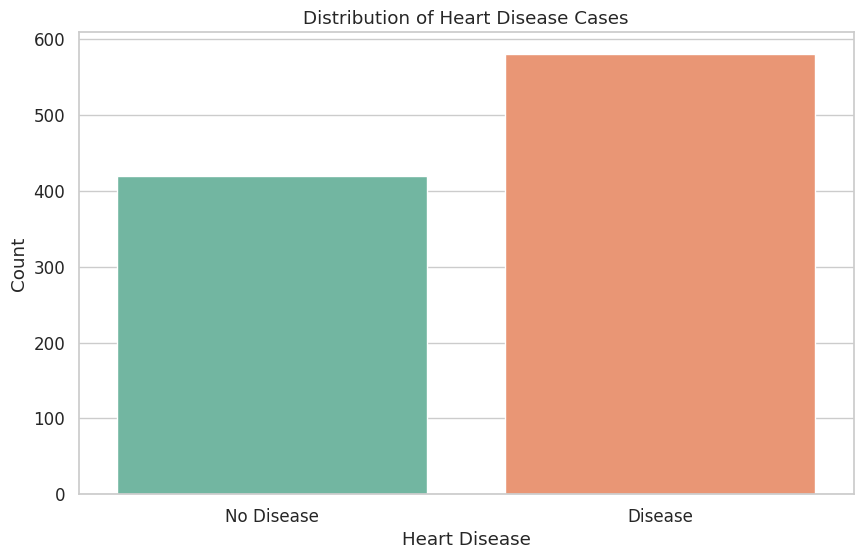

In [ ]:
# target variable analysis
sns.countplot(x='target', data=data, palette=['#66c2a5', '#fc8d62'])
plt.title("Distribution of Heart Disease Cases")
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

In [ ]:
# Percentages
target_counts = data['target'].value_counts(normalize=True) * 100
print(f"\nPercentage of patients WITH heart disease: {target_counts[1]:.2f}%")
print(f"Percentage of patients WITHOUT heart disease: {target_counts[0]:.2f}%")


Percentage of patients WITH heart disease: 58.00%
Percentage of patients WITHOUT heart disease: 42.00%


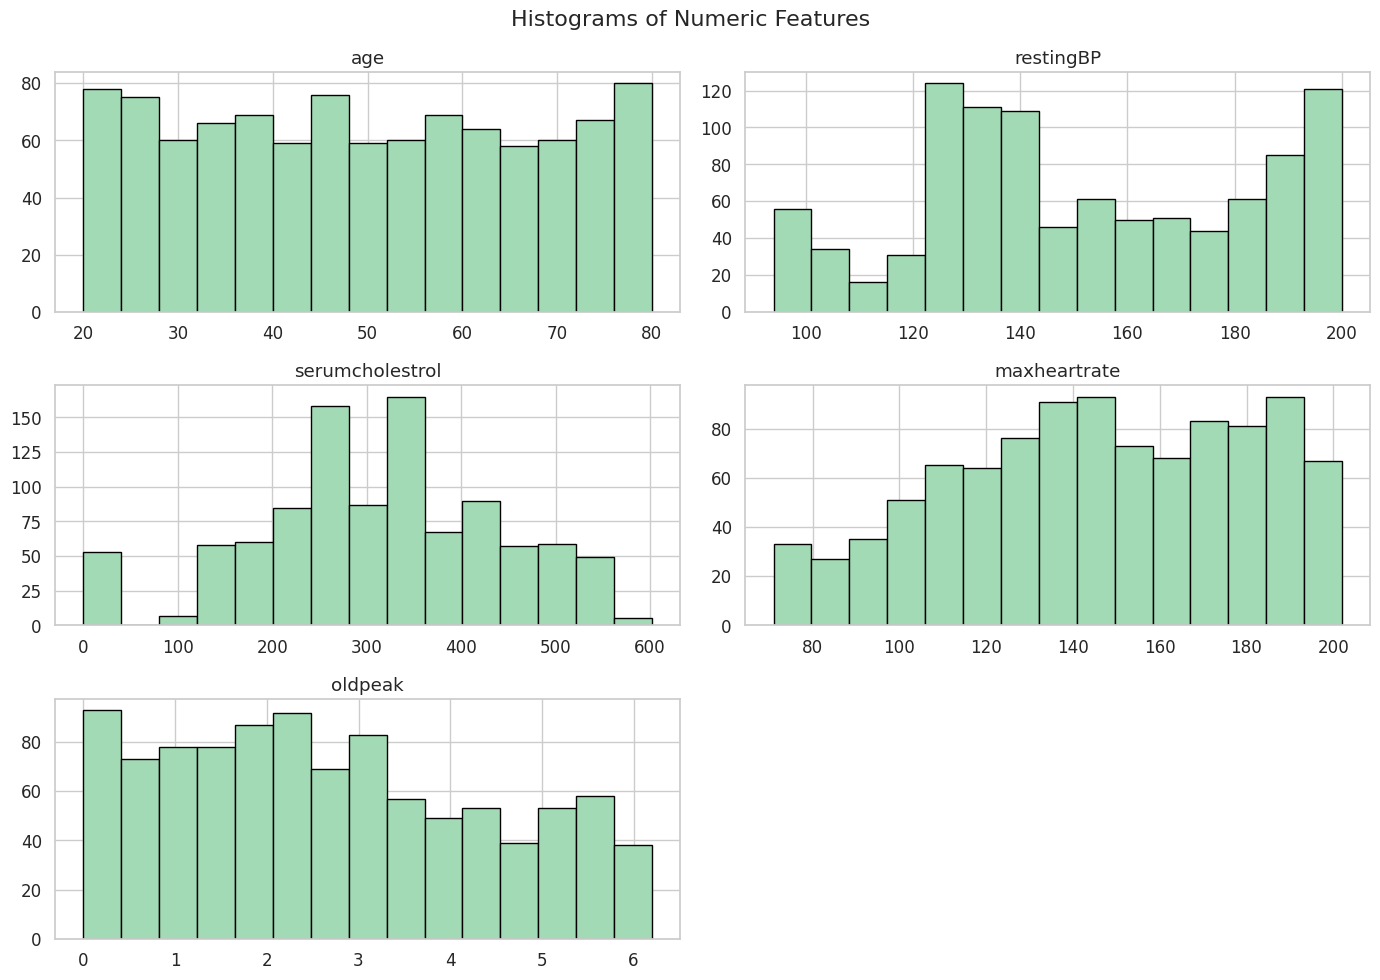

In [ ]:
# Numeric Features – Distribution
numeric_cols = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']

data[numeric_cols].hist(bins=15, figsize=(14, 10), color="#a1dab4", edgecolor="black")
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

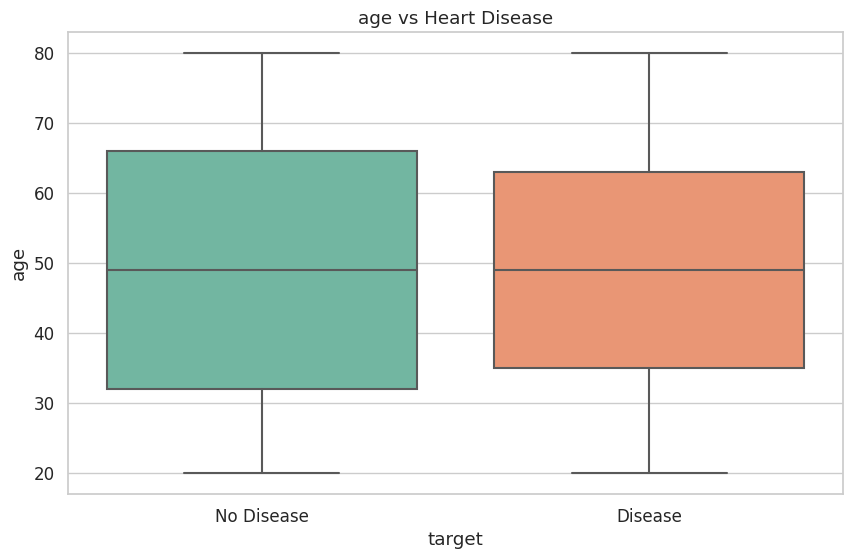

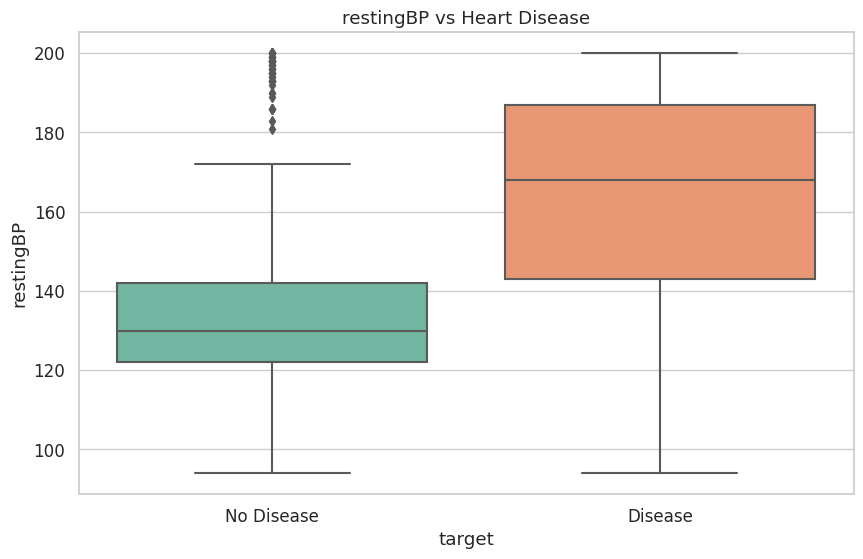

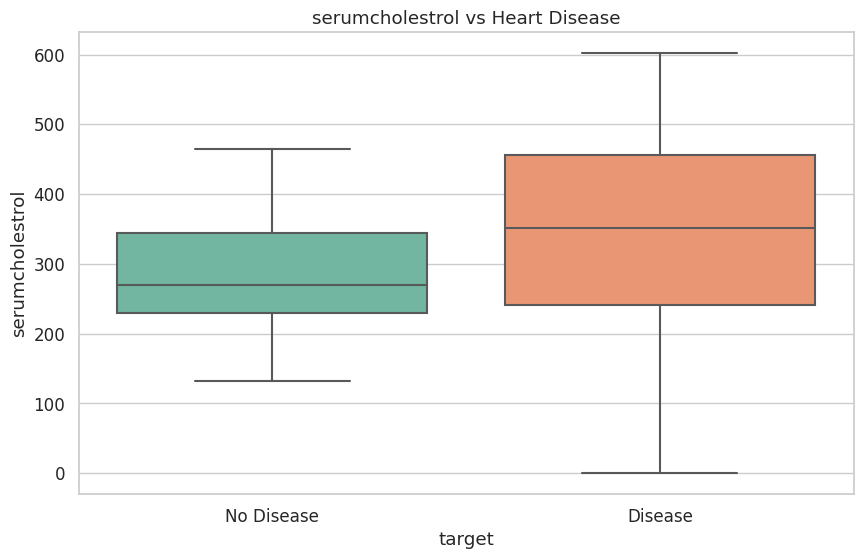

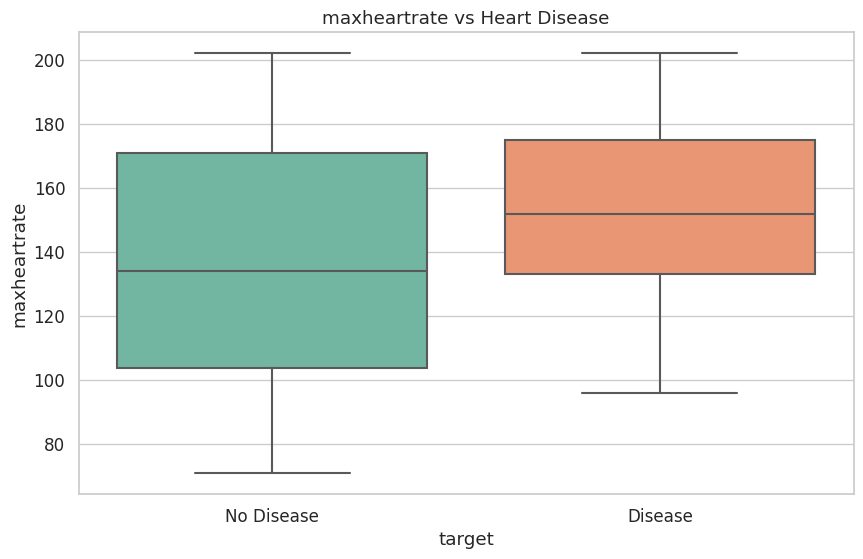

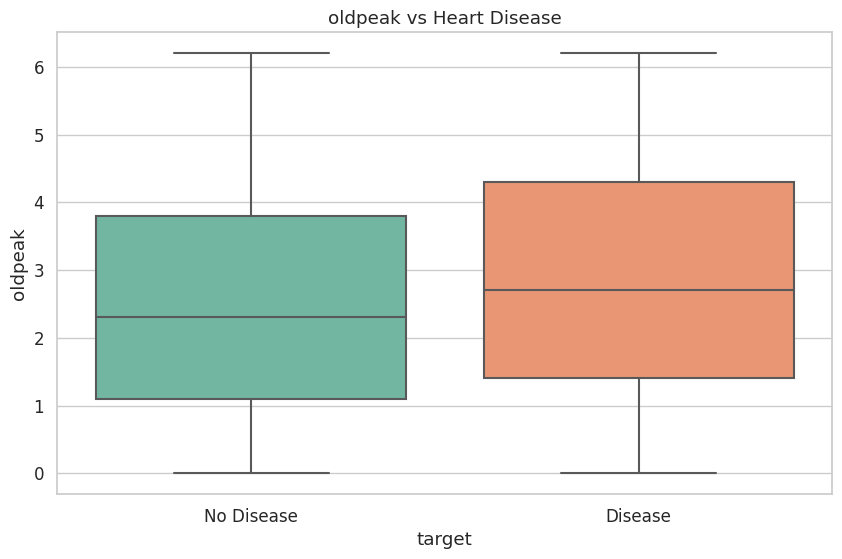

In [ ]:
# Boxplots per Target (Outlier Detection)
for col in numeric_cols:
    sns.boxplot(data=data, x='target', y=col, palette='Set2')
    plt.title(f'{col} vs Heart Disease')
    plt.xticks([0, 1], ['No Disease', 'Disease'])
    plt.show()

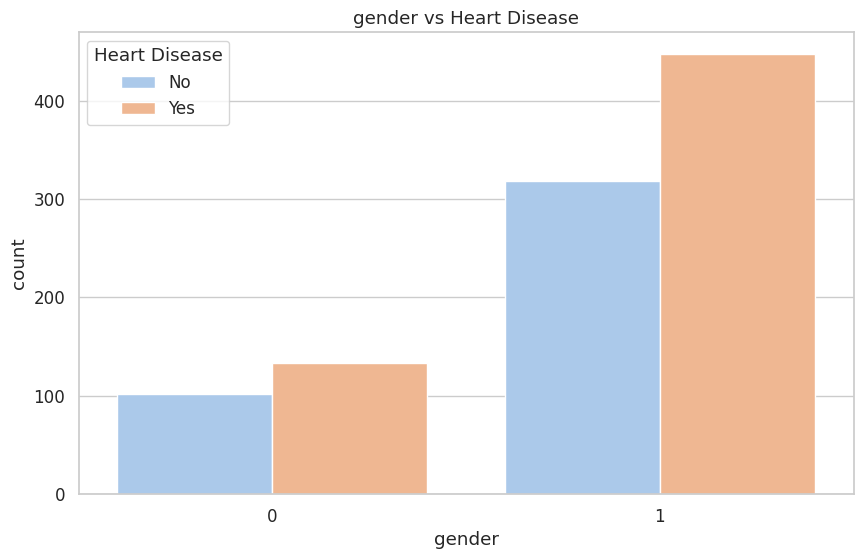

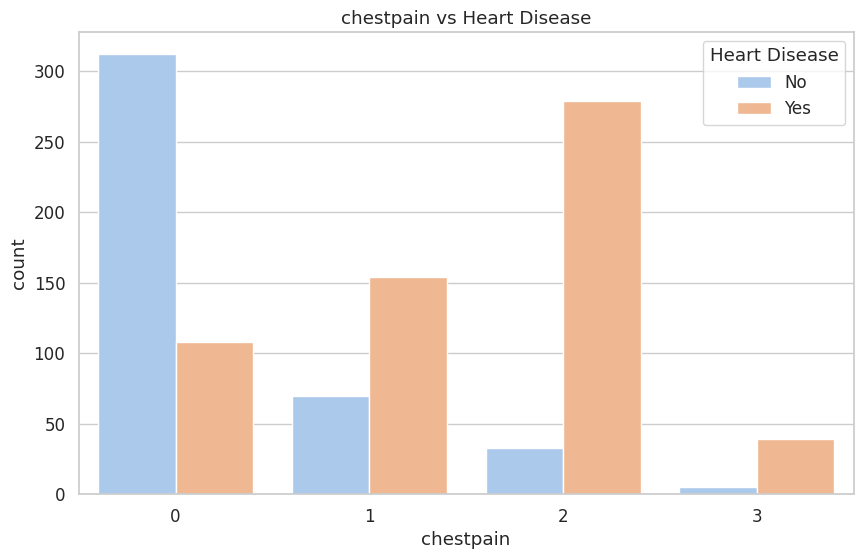

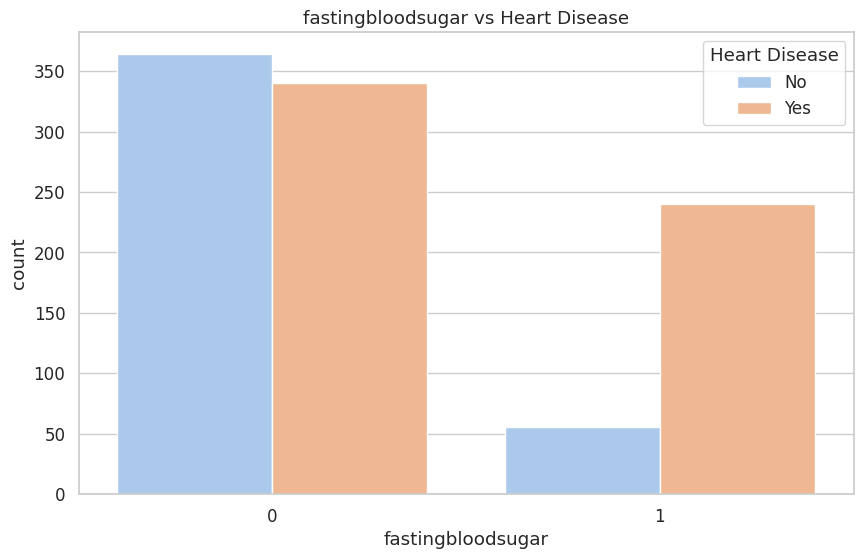

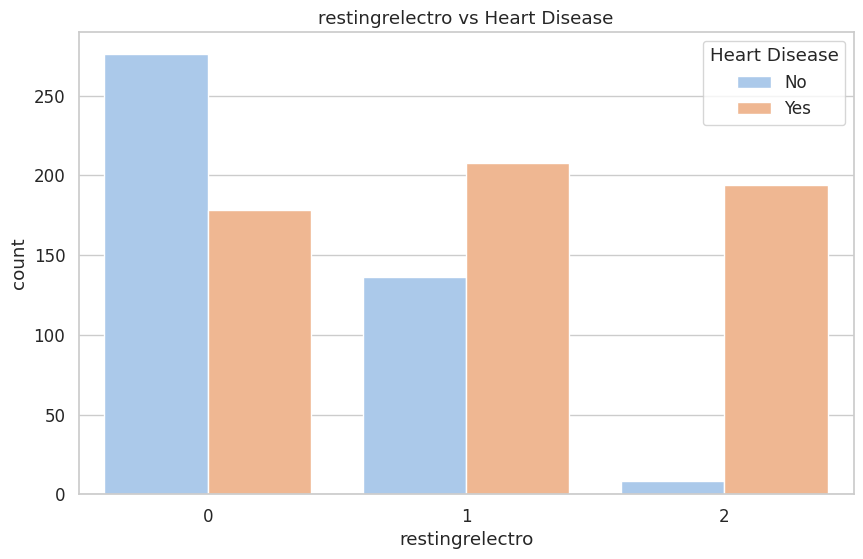

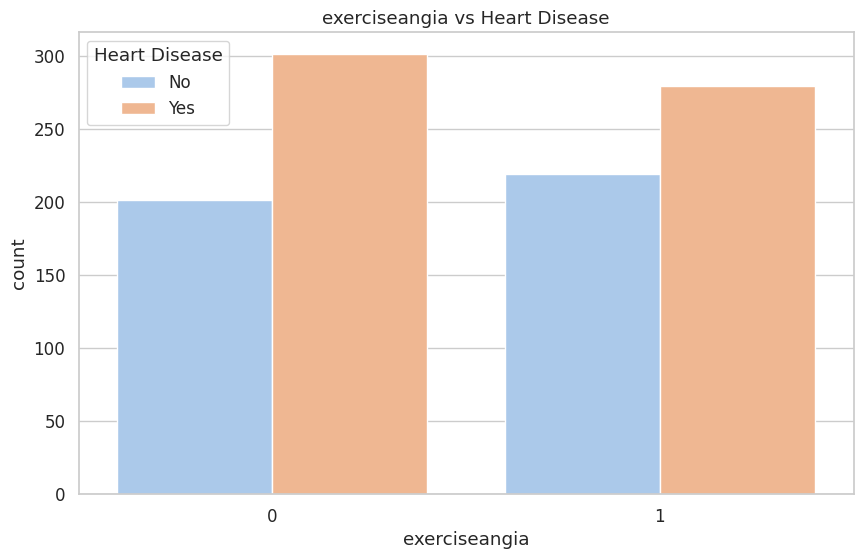

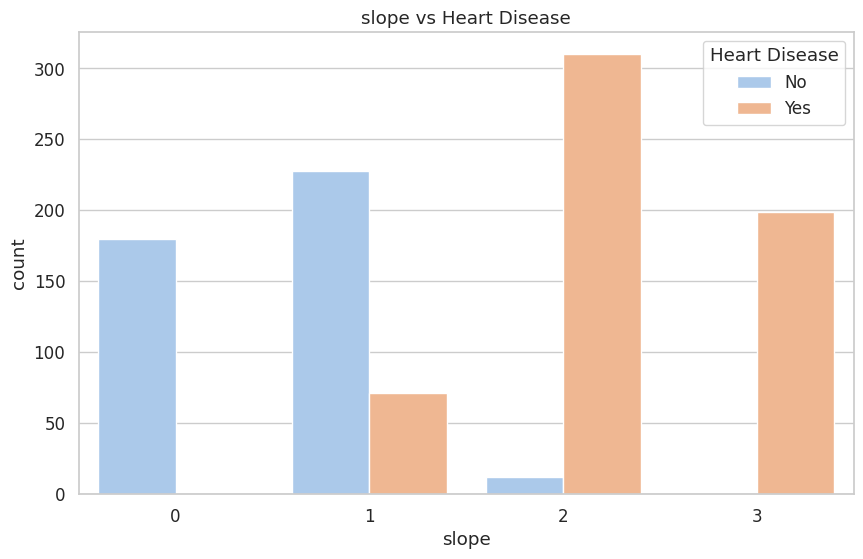

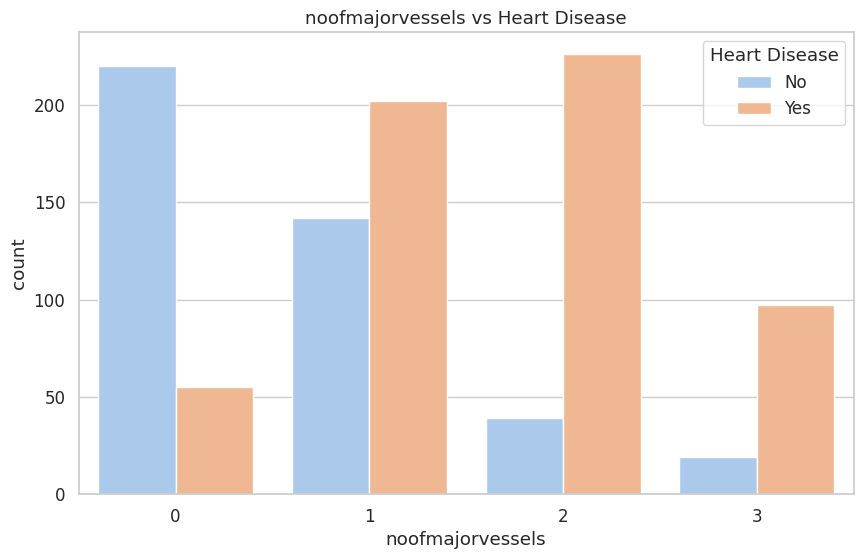

In [ ]:
# Categorical Features vs Target
categorical_cols = ['gender', 'chestpain', 'fastingbloodsugar', 
                    'restingrelectro', 'exerciseangia', 'slope', 'noofmajorvessels']

for col in categorical_cols:
    sns.countplot(data=data, x=col, hue='target', palette='pastel')
    plt.title(f'{col} vs Heart Disease')
    plt.legend(title='Heart Disease', labels=['No', 'Yes'])
    plt.show()

###  Why Are Some `int64` Columns Treated as Categorical?

Although all columns in the dataset are stored as numerical types (`int64` or `float64`), some features represent **categories or discrete states**, not continuous measurements. These are known as **nominal or ordinal categorical features**, and treating them properly is important for meaningful visualization and model performance.

Here’s a breakdown of those features along with their real-world meaning:

| Feature              | Description                                               | Values and Meaning                                                                 |
|----------------------|-----------------------------------------------------------|-------------------------------------------------------------------------------------|
| `gender`             | Biological sex of the patient                             | `0`: Female, `1`: Male                                                              |
| `chestpain`          | Type of chest pain experienced                            | `0`: Typical angina, `1`: Atypical angina, `2`: Non-anginal pain, `3`: Asymptomatic |
| `fastingbloodsugar`  | Fasting blood sugar > 120 mg/dl                           | `0`: False, `1`: True                                                               |
| `restingrelectro`    | Resting electrocardiographic results                      | `0`: Normal, `1`: ST-T wave abnormality, `2`: Left ventricular hypertrophy          |
| `exerciseangia`      | Exercise-induced angina                                   | `0`: No, `1`: Yes                                                                   |
| `slope`              | Slope of the peak exercise ST segment                     | `0`: Upsloping, `1`: Flat, `2`: Downsloping                                         |
| `noofmajorvessels`   | No. of major vessels colored by fluoroscopy (0–3)         | `0`, `1`, `2`, `3` — count of blocked vessels                                       |

These features are **encoded as integers** for storage efficiency but are best treated as **categorical** for analysis and modeling.

```python
#   Convert selected features to categorical type
categorical_features = ['gender', 'chestpain', 'fastingbloodsugar',
                        'restingrelectro', 'exerciseangia', 'slope', 'noofmajorvessels']

for col in categorical_features:
    df[col] = df[col].astype('category')


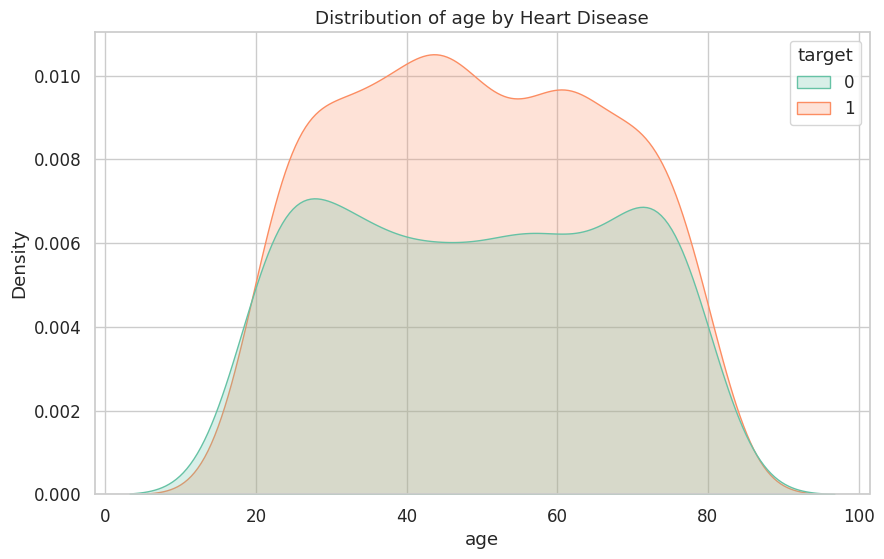

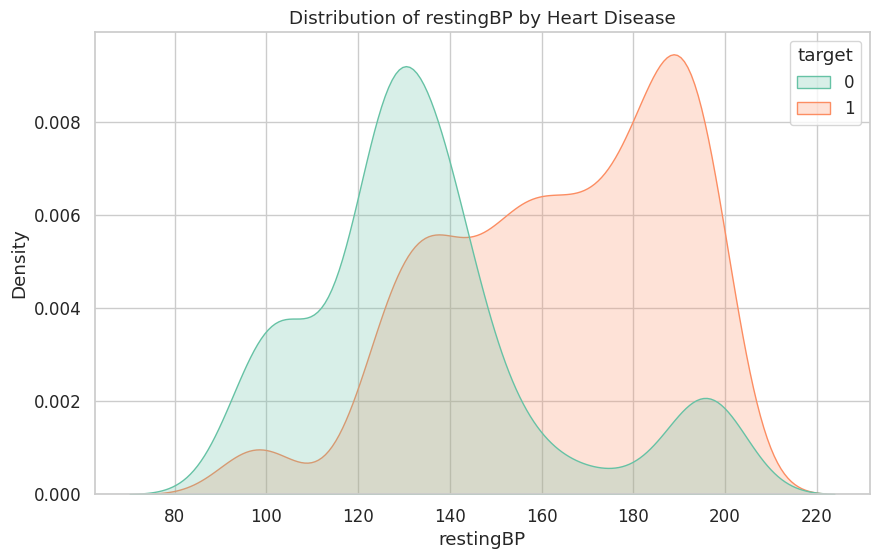

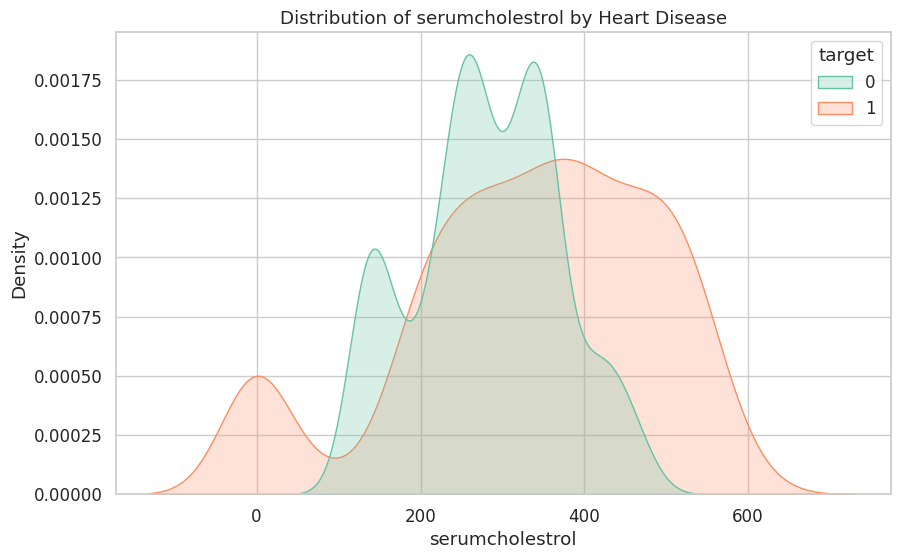

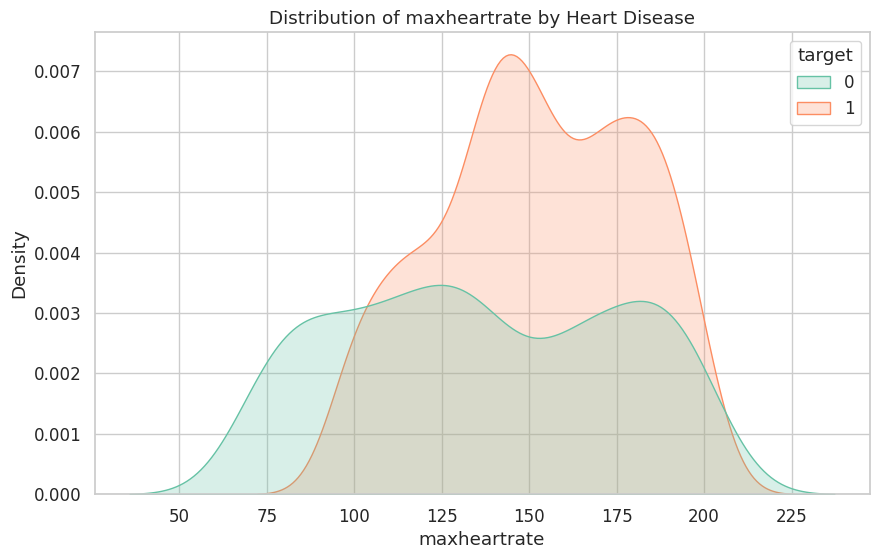

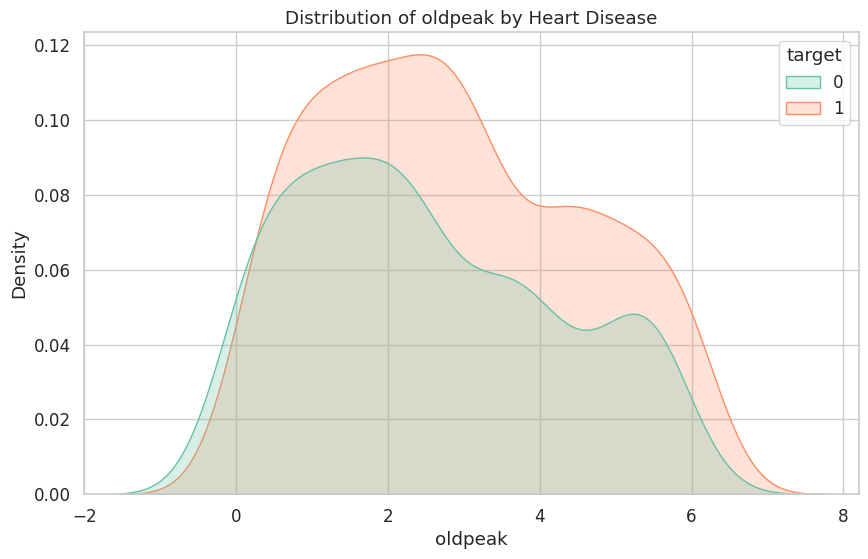

In [ ]:
# KDE Plots – Distribution by Class
import warnings
warnings.filterwarnings('ignore')
for col in numeric_cols:
    sns.kdeplot(data=data, x=col, hue='target', fill=True, palette='Set2')
    plt.title(f'Distribution of {col} by Heart Disease')
    plt.show()

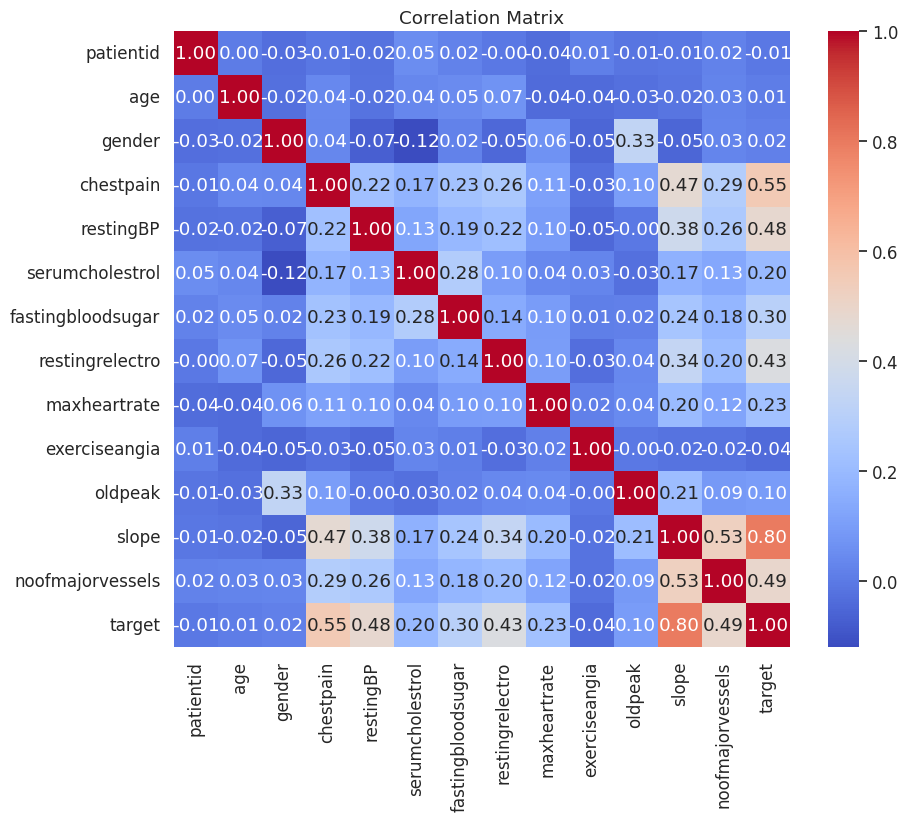

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:

# Sample function to display crosstab tables and normalized percentages
def print_crosstab_info(feature):
    print(f"\n--- Crosstab for {feature} vs Heart Disease ---")
    
    # Raw counts crosstab
    counts = pd.crosstab(data[feature], data['target'])
    print("\nRaw Counts:")
    print(counts)
    
    # Percentage crosstab (normalized by row to get distribution per category)
    percentages = pd.crosstab(data[feature], data['target'], normalize='index') * 100
    print("\nPercentages (% within each category):")
    print(percentages.round(2))
    
    # Optional: interpret one row
    for category in counts.index:
        no_disease_pct = percentages.loc[category, 0]
        disease_pct = percentages.loc[category, 1]
        print(f"  - {feature} = {category}: {disease_pct:.1f}% have heart disease, {no_disease_pct:.1f}% do not.")
        
# List of categorical features to analyze
categorical_features = ['gender', 'chestpain', 'fastingbloodsugar',
                        'restingrelectro', 'exerciseangia', 'slope', 'noofmajorvessels']

# Run for each feature
for feature in categorical_features:
    print_crosstab_info(feature)



--- Crosstab for gender vs Heart Disease ---

Raw Counts:
target    0    1
gender          
0       102  133
1       318  447

Percentages (% within each category):
target      0      1
gender              
0       43.40  56.60
1       41.57  58.43
  - gender = 0: 56.6% have heart disease, 43.4% do not.
  - gender = 1: 58.4% have heart disease, 41.6% do not.

--- Crosstab for chestpain vs Heart Disease ---

Raw Counts:
target       0    1
chestpain          
0          312  108
1           70  154
2           33  279
3            5   39

Percentages (% within each category):
target         0      1
chestpain              
0          74.29  25.71
1          31.25  68.75
2          10.58  89.42
3          11.36  88.64
  - chestpain = 0: 25.7% have heart disease, 74.3% do not.
  - chestpain = 1: 68.8% have heart disease, 31.2% do not.
  - chestpain = 2: 89.4% have heart disease, 10.6% do not.
  - chestpain = 3: 88.6% have heart disease, 11.4% do not.

--- Crosstab for fastingbloodsugar v

## Crosstab Analysis: Categorical Features vs Heart Disease

Below is a detailed analysis of how various categorical features relate to the presence (`target = 1`) or absence (`target = 0`) of heart disease in the dataset.

---

### 1. Gender vs Heart Disease

| Gender | No Heart Disease (0) | Heart Disease (1) | % with Disease |
|--------|---------------------|-------------------|----------------|
| 0 (Female) | 102                 | 133               | 56.6%          |
| 1 (Male)   | 318                 | 447               | 58.4%          |

> Both genders show a similar proportion (~57-58%) of heart disease cases.

---

### 2. Chest Pain Type vs Heart Disease

| Chest Pain Type | No Heart Disease (0) | Heart Disease (1) | % with Disease |
|-----------------|----------------------|-------------------|----------------|
| 0 (Typical Angina)     | 312                  | 108               | 25.7%          |
| 1 (Atypical Angina)    | 70                   | 154               | 68.8%          |
| 2 (Non-anginal Pain)   | 33                   | 279               | 89.4%          |
| 3 (Asymptomatic)       | 5                    | 39                | 88.6%          |

> Chest pain types 2 and 3 have a much higher association with heart disease (~89%).

---

### 3. Fasting Blood Sugar vs Heart Disease

| Fasting Blood Sugar > 120 mg/dl | No Heart Disease (0) | Heart Disease (1) | % with Disease |
|---------------------------------|----------------------|-------------------|----------------|
| 0 (False)                      | 364                  | 340               | 48.3%          |
| 1 (True)                       | 56                   | 240               | 81.1%          |

> Elevated fasting blood sugar strongly correlates with heart disease (81.1%).

---

### 4. Resting Electrocardiographic Results vs Heart Disease

| Resting ECG Result       | No Heart Disease (0) | Heart Disease (1) | % with Disease |
|-------------------------|----------------------|-------------------|----------------|
| 0 (Normal)              | 276                  | 178               | 39.2%          |
| 1 (ST-T wave abnormality) | 136                  | 208               | 60.5%          |
| 2 (Left ventricular hypertrophy) | 8                    | 194               | 96.0%          |

> Left ventricular hypertrophy shows a very high risk (~96%) of heart disease.

---

### 5. Exercise-Induced Angina vs Heart Disease

| Exercise Angina | No Heart Disease (0) | Heart Disease (1) | % with Disease |
|-----------------|----------------------|-------------------|----------------|
| 0 (No)          | 201                  | 301               | 59.96%         |
| 1 (Yes)         | 219                  | 279               | 56.02%         |

> Both groups show similar heart disease rates (~56-60%), indicating a mild association.

---

### 6. Slope of ST Segment vs Heart Disease

| Slope | No Heart Disease (0) | Heart Disease (1) | % with Disease |
|-------|----------------------|-------------------|----------------|
| 0 (Upsloping)       | 180                  | 0                 | 0%             |
| 1 (Flat)            | 228                  | 71                | 23.7%          |
| 2 (Downsloping)     | 12                   | 310               | 96.3%          |
| 3 (Unknown/Other)*  | 0                    | 199               | 100%           |

> Downsloping ST segment slope and category '3' are highly indicative of heart disease.

---

### 7. Number of Major Vessels Colored by Fluoroscopy vs Heart Disease

| Number of Vessels | No Heart Disease (0) | Heart Disease (1) | % with Disease |
|-------------------|----------------------|-------------------|----------------|
| 0                 | 220                  | 55                | 20.0%          |
| 1                 | 142                  | 202               | 58.7%          |
| 2                 | 39                   | 226               | 85.3%          |
| 3                 | 19                   | 97                | 83.6%          |

> Increasing number of blocked vessels strongly correlates with heart disease risk.

---

### Summary:

- **Chest pain type**, **fasting blood sugar**, **resting ECG results**, **ST segment slope**, and **number of major vessels** show strong association with heart disease presence.
- Gender and exercise-induced angina show mild association.
- These insights guide feature importance considerations and help communicate risk factors to stakeholders and clinicians.

---

*Note: Category '3' in slope may represent a data encoding choice and should be verified with domain knowledge or dataset documentation.



In [ ]:
# preprocessing
data.drop("patientid", axis=1, inplace=True)

In [ ]:
# Split X and y
X = data.drop("target", axis=1)
y = data["target"]

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training/testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# train the models
nb_model = GaussianNB()
svm_model = svm.SVC()


nb_model.fit(X_train, y_train)
svm_model.fit(X_train,y_train)

SVC()

In [ ]:
# Predictions
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

In [ ]:
# Evaluation - Classification Reports

print("\n Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

print("\n SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


 Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        84
           1       0.93      0.97      0.95       116

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200


 SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        84
           1       0.96      0.98      0.97       116

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



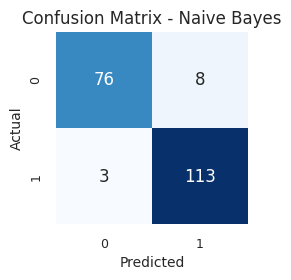

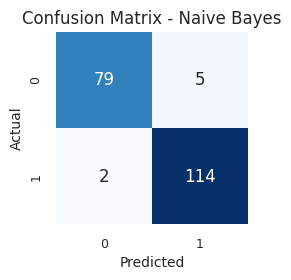

In [ ]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3)) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
                annot_kws={"size": 12})
    plt.xlabel("Predicted", fontsize=10)
    plt.ylabel("Actual", fontsize=10)
    plt.title(title, fontsize=12)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

# Plot both confusion matrices

plot_conf_matrix(y_test, y_pred_nb, "Confusion Matrix - Naive Bayes")
plot_conf_matrix(y_test, y_pred_svm, "Confusion Matrix - Naive Bayes")

In [ ]:
# Instantiate and train XGBoost model
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_clf.predict(X_test)


Classification Report - XGBoost:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        84
           1       0.99      0.99      0.99       116

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



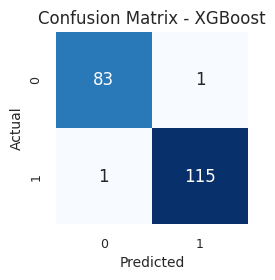

In [ ]:
# Classification report
print("Classification Report - XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
plot_conf_matrix(y_test, y_pred_xgb, "Confusion Matrix - XGBoost")


In [ ]:
# Save the model to a file
joblib.dump(xgb_clf, 'xgboost_model.joblib')

print("XGBoost model saved to 'xgboost_model.joblib'")

XGBoost model saved to 'xgboost_model.joblib'


In [ ]:
# SHAP initialization
explainer = shap.Explainer(xgb_clf)
shap_values = explainer(X_test)


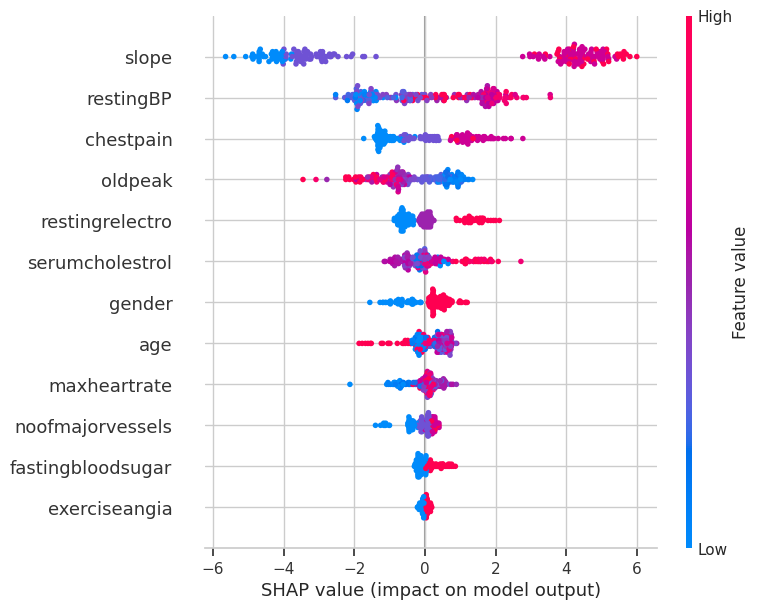

In [ ]:
# summary plot (Global Feature Importance)
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

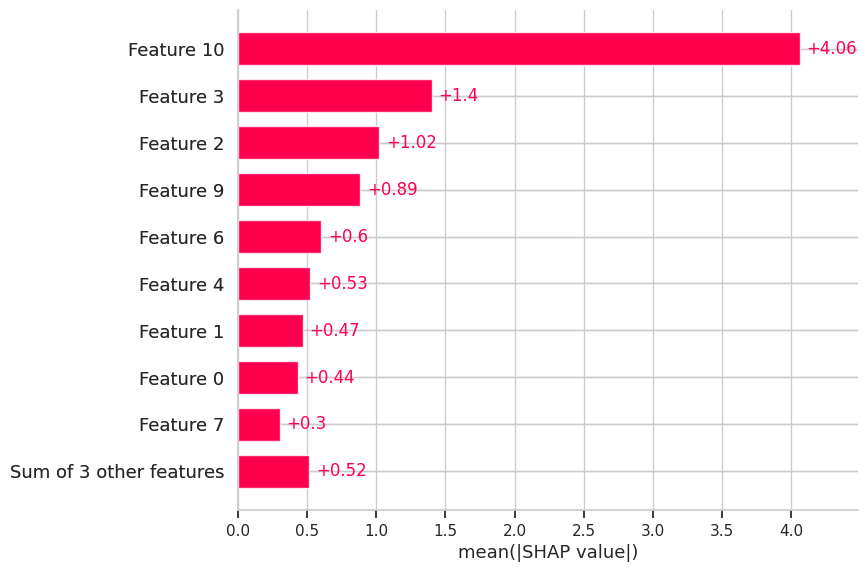

In [ ]:
# Bar Plot (Mean absolute SHAP values)
shap.plots.bar(shap_values, max_display=10)


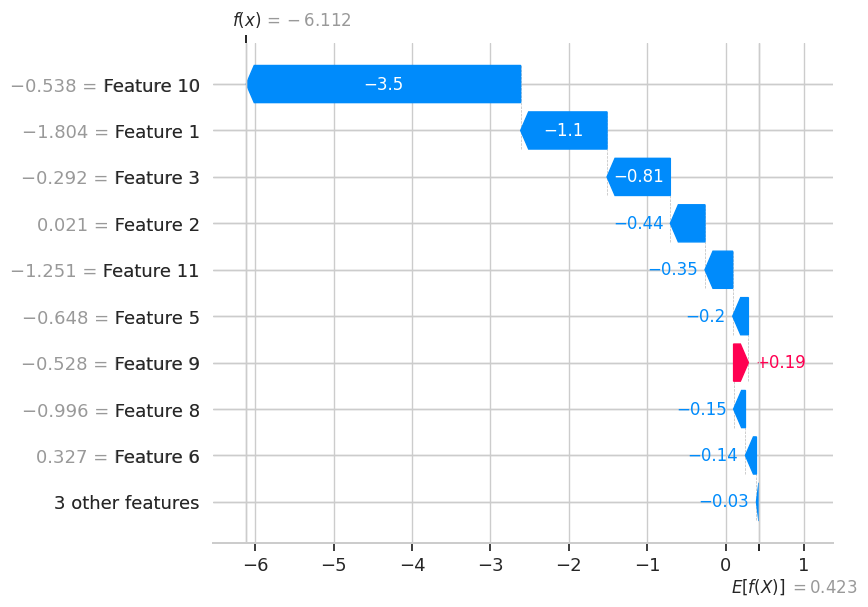

In [ ]:
# SHAP Waterfall Plot
shap.plots.waterfall(shap_values[0])

Stacking Classifier Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        84
           1       0.99      0.99      0.99       116

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



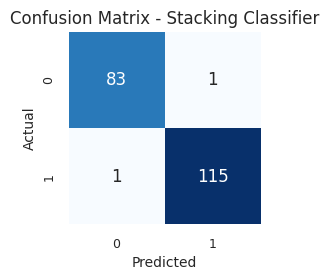

In [ ]:
# Define base models
base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

# Define meta-model
meta_model = LogisticRegression()

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=True  # pass original features to meta-model
)

# Train stacking classifier
stacking_clf.fit(X_train, y_train)

# Predict on test set
y_pred_stack = stacking_clf.predict(X_test)

# Evaluation
print("Stacking Classifier Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

# Confusion matrix 

plot_conf_matrix(y_test, y_pred_stack, "Confusion Matrix - Stacking Classifier")


In [ ]:
# Saving the model
!pip install joblib
import joblib
joblib.dump(stacking_clf,'Stacking_classifier.pkl')

NameError: name 'stacking_clf' is not defined

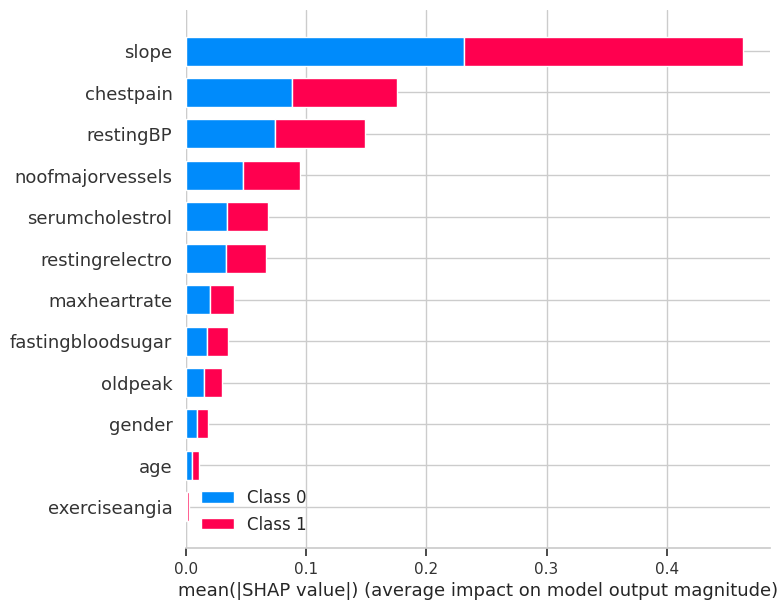

  0%|          | 0/50 [00:00<?, ?it/s]

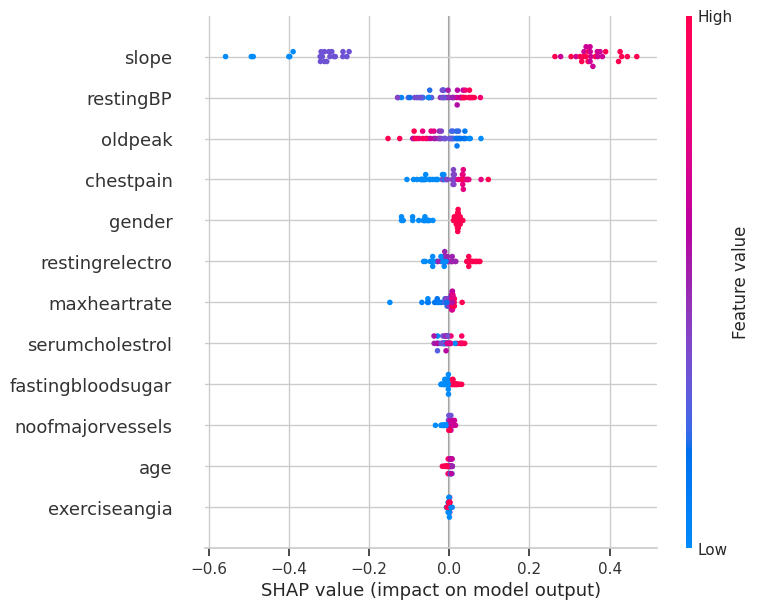

In [ ]:
explainer_rf = shap.TreeExplainer(stacking_clf.named_estimators_['rf'])
shap_values_rf = explainer_rf.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values_rf, X_test, feature_names=X.columns, plot_type="bar")

# If you want to explain the entire stacking model output:
# KernelExplainer can be slow; so sample a subset for background data:

import numpy as np
background = shap.sample(X_train, 100, random_state=42)
explainer_stack = shap.KernelExplainer(stacking_clf.predict_proba, background)
shap_values_stack = explainer_stack.shap_values(X_test[:50])  # Explain only first 50 samples for speed

# Summary plot for the first class
shap.summary_plot(shap_values_stack[1], X_test[:50], feature_names=X.columns)

In [ ]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
joblib.dump(model,'random_forest ')